In [245]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LaTeX has been enabled for text rendering.


### Definição da Planta

In [246]:
experiment_config_filename = 'exp-01'

with open(f"experiment-datas/{experiment_config_filename}.json", encoding='utf-8') as f:
  config = json.load(f)

plant = ds.StateSpace(data=config["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [247]:
# x0 = np.array([[1.0], [0.1]], dtype=np.float32)
x0 = np.array([[0.1], [-0.5]], dtype=np.float32)
plant_output, time_history, signal_control = open_loop(
    x0, config, u_constant=0.0)

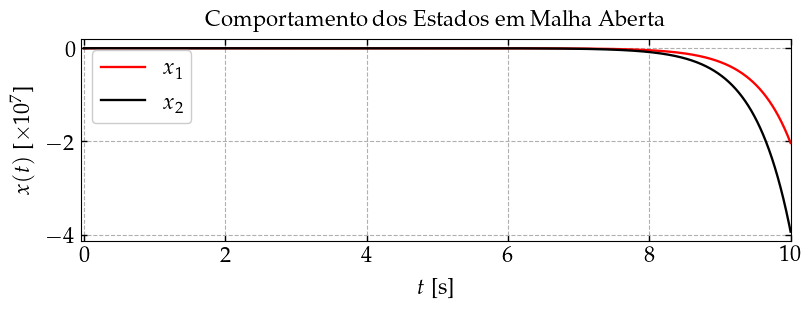

In [248]:
fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], time_history, plant_output,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Aberta',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

### Projeto do Controlador e do ETM

In [249]:
def solve_problem(
    h: float,
    υ: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))
  # Ktil = cp.Parameter((n_u, n_x), value=np.array([[1, -3.0]]))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + (h - ω) * Θ4

  def get_Λ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T

    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_23 = np.zeros((2 * n_x, n_x))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Λ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ψtil >> eps * np.eye(n_x)]
  constraints += [Ξtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  # Solve the problem using the MOSEK solver
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # Initialize variables to store results
  design_results = None

  # Display the results
  if prob.status not in ["infeasible", "unbounded"]:
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv
    K = Ktil.value @ Xinv
    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
  else:
    design_results = None

  return design_results

In [250]:
sampling_period = 5e-2
υ = 1e-1

prob_results = solve_problem(h=sampling_period, υ=υ)

if prob_results is not None:
  Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
  K = prob_results['controller']['K']
  P, S2 = prob_results['lyapunov']

  display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
  display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
  display(Math(rf'P = {tex.mat2tex(P)}'))

  display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [251]:
config["design_params"]['h'] = sampling_period
config["design_params"]['iet_max'] = 5 * sampling_period

In [252]:
y_hist, time_history, u_hist, event_times = closed_loop_setm(
    x0, config, prob_results)

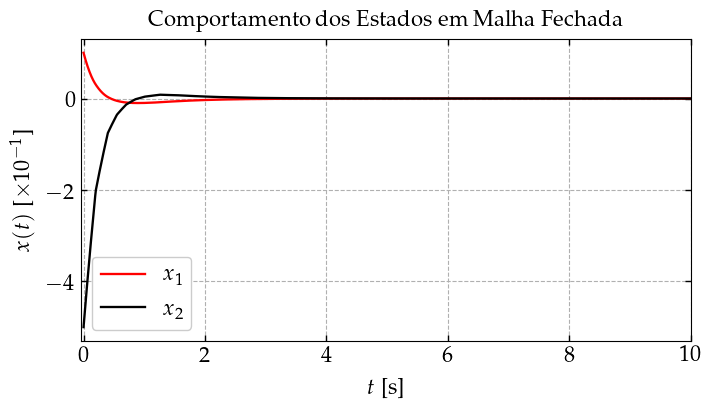

In [253]:
fig = plt.figure(figsize=(7, 4), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], time_history, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Fechada',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

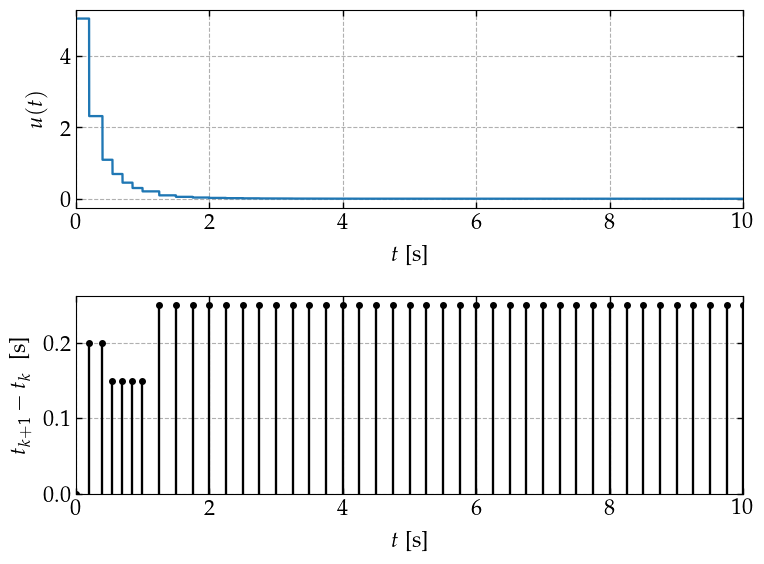

In [254]:
mosaic = [['control'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(event_times)

for i in range(plant.nu):
  gph.plot(
      axs['control'], time_history, u_hist, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': colors_list[0], "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], event_times, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time_history[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': time_history[-1]}})

plt.tight_layout(pad=2.)

In [255]:
inter_event_times / sampling_period

array([0., 4., 4., 3., 3., 3., 3., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5.])

In [13]:
import numpy as np
from collections import defaultdict
import networkx as nx


def projective_eps_net(eps):
  N = int(np.ceil(np.pi / eps))
  theta = np.linspace(0, np.pi, N, endpoint=False)
  X = np.vstack([np.cos(theta), np.sin(theta)]).T
  return X, theta


class RecurrenceCache:
  def __init__(self):
    self.cache = {}

  def get_k_sequence(self, x0, config, prob_results):
    key = tuple(np.round(x0, 12))
    if key in self.cache:
      return self.cache[key]

    h = config["design_params"]["h"]

    event_times = recurrence_model(x0, config, prob_results)
    inter_event_times = nm.compute_deltas(event_times[1:])
    k_seq = tuple(int(round(t / h)) for t in inter_event_times)

    self.cache[key] = k_seq
    return k_seq


def build_symbolic_graph_projective(l, eps, config, prob_results):

  cache = RecurrenceCache()
  initial_states, theta = projective_eps_net(eps)
  partition = defaultdict(list)

  for x0, th in zip(initial_states, theta):
    k_seq = cache.get_k_sequence(x0, config, prob_results)
    if len(k_seq) >= l:
      word = tuple(k_seq[:l])
      partition[word].append(th)

  G = nx.DiGraph()

  for x0 in initial_states:
    k_seq = cache.get_k_sequence(x0, config, prob_results)
    if len(k_seq) > l:
      for i in range(len(k_seq) - l):
        state_curr = tuple(k_seq[i:i+l])
        state_next = tuple(k_seq[i+1:i+l+1])
        k_out = state_curr[0]

        G.add_edge(state_curr, state_next,
                   weight=k_out, label=str(k_out))

  for word, th_list in partition.items():
    if word not in G.nodes:
      G.add_node(word)
    G.nodes[word]["theta_points"] = np.array(th_list)

  d_min = np.pi / len(theta)
  rc = d_min
  kappa = 1.0

  print("=== Geometric Sampling Report ===")
  print(f"Number of samples: {len(theta)}")
  print(f"Angular covering radius rc = {rc:e}")
  print(f"Min angular distance = {d_min:e}")
  print(f"Condition number kappa = {kappa}")
  print(f"Quasi-infinitesimal: {d_min < 1e-6}")

  print("=== Symbolic Graph Report ===")
  print(f"Number of ℓ-symbolic cells: {len(partition)}")
  print(f"Graph nodes: {G.number_of_nodes()}")
  print(f"Graph edges: {G.number_of_edges()}")

  return initial_states, theta, partition, G, d_min, rc, kappa


l = 2
eps = 1e-3

initial_states, theta, partition, G_sampled, d_min, rc, kappa = build_symbolic_graph_projective(
    l=l,
    eps=eps,
    config=config,
    prob_results=prob_results
)

=== Geometric Sampling Report ===
Number of samples: 3142
Angular covering radius rc = 9.998704e-04
Min angular distance = 9.998704e-04
Condition number kappa = 1.0
Quasi-infinitesimal: False
=== Symbolic Graph Report ===
Number of ℓ-symbolic cells: 7
Graph nodes: 7
Graph edges: 11


In [14]:
import networkx as nx
from pyvis.network import Network


def visualize_sequence_in_graph(G, sequence=None, filename="symbolic_graph.html"):
  """
  G: grafo NetworkX
  sequence: lista de estados [s1, s2, s3, ...] que representa a trajetória desejada
  """
  net = Network(notebook=True, directed=True, width="100%", height="95vh")

  sccs = list(nx.strongly_connected_components(G))
  attractor_nodes = set()
  for scc in sccs:
    if len(scc) > 1:
      attractor_nodes.update(scc)
    else:
      node = next(iter(scc))
      if G.has_edge(node, node):
        attractor_nodes.add(node)

  node_id_map = {node: str(i) for i, node in enumerate(G.nodes)}

  for node, node_id in node_id_map.items():
    if sequence and node in sequence:
      color = "#00BFFF"
    elif node in attractor_nodes:
      color = "#FF8C00"
    else:
      color = "#97c2fc"

    net.add_node(
        node_id,
        label=str(node),
        title=f"Symbolic state {node}",
        shape="circle",
        size=35,
        color=color,
        font={"size": 16, "face": "Arial", "align": "center"},
    )

  for u, v, data in G.edges(data=True):
    u_id = node_id_map[u]
    v_id = node_id_map[v]
    weight = data.get("weight")

    is_in_sequence = False
    if sequence:
      for i in range(len(sequence) - 1):
        if u == sequence[i] and v == sequence[i + 1]:
          is_in_sequence = True
          break

    if is_in_sequence:
      edge_color = "#FF00FF"
      width = 3
    elif u in attractor_nodes and v in attractor_nodes:
      edge_color = "#FF4500"
      width = 2
    else:
      edge_color = "#888"
      width = 1

    if weight is not None:
      net.add_edge(u_id, v_id, label=str(weight), title=str(weight),
                   color=edge_color, width=width)
    else:
      net.add_edge(u_id, v_id, color=edge_color, width=width)

  net.force_atlas_2based(
      gravity=-50, central_gravity=0.01, spring_length=100)

  net.show(filename)


_seq = tuple(int(round(t / config['design_params']['h']))
             for t in inter_event_times)
sequence_pairs = [(_seq[i], _seq[i+1])
                  for i in range(len(_seq)-1)]

visualize_sequence_in_graph(G_sampled, sequence_pairs, "sampled_model.html")

sampled_model.html


In [15]:
import numpy as np
import itertools
import networkx as nx
import cvxpy as cp
import scipy.linalg


# ============================================================
# System matrices
# ============================================================

def A_matrix(v, A, B, K):
  expAv = scipy.linalg.expm(A * v)

  if np.linalg.matrix_rank(A) == A.shape[0]:
    Gamma = np.linalg.solve(A, expAv - np.eye(A.shape[0]))
  else:
    Gamma = np.zeros_like(A)
    term = np.eye(A.shape[0])
    for j in range(30):
      Gamma += term * (v ** (j + 1)) / np.math.factorial(j + 1)
      term = term @ A

  return expAv + Gamma @ B @ K


def Q_matrix(v, A, B, K, Psi, Xi):
  Av = A_matrix(v, A, B, K)
  I = np.eye(Av.shape[0])
  return Av.T @ Psi @ Av - (I - Av).T @ Xi @ (I - Av)


# ============================================================
# Exact feasibility test via SDP
# ============================================================

def is_word_feasible_exact(word, h, A, B, K, Psi, Xi):

  n = A.shape[0]
  assert n == 2, "Exact implementation currently assumes 2D."

  # Collect quadratic constraints
  M = np.eye(n)
  P_pos = []
  P_neg = []

  for k_i in word:

    for m in range(1, k_i):
      Qm = Q_matrix(h * m, A, B, K, Psi, Xi)
      P_pos.append(M.T @ Qm @ M)

    Qk = Q_matrix(h * k_i, A, B, K, Psi, Xi)
    P_neg.append(M.T @ Qk @ M)

    Ak = A_matrix(h * k_i, A, B, K)
    M = Ak @ M

  # SDP variable
  X = cp.Variable((n, n), PSD=True)

  constraints = []
  constraints.append(cp.trace(X) == 1)

  for P in P_pos:
    constraints.append(cp.trace(P @ X) >= 0)

  for R in P_neg:
    constraints.append(cp.trace(R @ X) <= 0)

  prob = cp.Problem(cp.Minimize(0), constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False)
  except:
    return False

  return prob.status in ["optimal", "optimal_inaccurate"]


# ============================================================
# Build complete ℓ-complete graph
# ============================================================

def build_complete_symbolic_graph_exact(l,
                                        K_set,
                                        h,
                                        A, B, K,
                                        Psi, Xi):

  words = list(itertools.product(K_set, repeat=l))
  feasible_words = []

  print("=== Testing Feasibility via SDP ===")

  for word in words:
    if is_word_feasible_exact(word, h, A, B, K, Psi, Xi):
      feasible_words.append(word)

  G = nx.DiGraph()

  for word in feasible_words:
    G.add_node(word)

  # Domino rule
  for word in feasible_words:
    suffix = word[1:]
    for k_next in K_set:
      next_word = suffix + (k_next,)
      if next_word in feasible_words:
        G.add_edge(word,
                   next_word,
                   weight=word[0],
                   label=str(word[0]))

  print("=== Symbolic Graph Report ===")
  print(f"Word length ℓ: {l}")
  print(f"|K|: {len(K_set)}")
  print(f"Total candidate words: {len(words)}")
  print(f"Feasible words: {len(feasible_words)}")
  print(f"Graph nodes: {G.number_of_nodes()}")
  print(f"Graph edges: {G.number_of_edges()}")

  return G

In [16]:
import scipy.linalg

l = 2
K_set = [1, 2, 3, 4, 5]
h = sampling_period

Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
K = prob_results['controller']['K']

A, B, _, _ = plant.export_matrices_jit()

G_complete = build_complete_symbolic_graph_exact(
    l=l,
    K_set=K_set,
    h=h,
    A=A,
    B=B,
    K=K,
    Psi=Ψ,
    Xi=Ξ
)

=== Testing Feasibility via SDP ===
=== Symbolic Graph Report ===
Word length ℓ: 2
|K|: 5
Total candidate words: 25
Feasible words: 7
Graph nodes: 7
Graph edges: 15


In [17]:
visualize_sequence_in_graph(G_complete, sequence_pairs, "complete_model.html")

complete_model.html


In [18]:
set(G_sampled.edges()).issubset(set(G_complete.edges()))

True

In [19]:
"""
Symbolic Graph Structural Analysis

This module performs structural and ergodic analysis of a symbolic traffic graph.

Requirements:
    networkx
    numpy

Graph assumptions:
    - G is a directed graph (nx.DiGraph)
    - Each edge has attribute 'weight' corresponding to emitted traffic (k)
"""

import networkx as nx
import numpy as np


# ---------------------------------------------------------------------
# Utility: Strongly Connected Components
# ---------------------------------------------------------------------

def analyze_connectivity(G):
  """
  Analyze strongly connected components.
  """
  scc = list(nx.strongly_connected_components(G))
  largest_scc = max(scc, key=len)
  is_strongly_connected = len(scc) == 1

  return {
      "num_scc": len(scc),
      "largest_scc_size": len(largest_scc),
      "is_strongly_connected": is_strongly_connected,
  }


# ---------------------------------------------------------------------
# Minimum and Maximum Cycle Mean (Karp's algorithm)
# ---------------------------------------------------------------------

def karp_minimum_cycle_mean(G):
  """
  Compute minimum cycle mean using Karp's algorithm.
  """
  nodes = list(G.nodes())
  n = len(nodes)
  index = {node: i for i, node in enumerate(nodes)}

  dp = np.full((n + 1, n), np.inf)
  dp[0, :] = 0

  for k in range(1, n + 1):
    for v in nodes:
      i = index[v]
      for u in G.predecessors(v):
        j = index[u]
        w = G[u][v]["weight"]
        dp[k, i] = min(dp[k, i], dp[k - 1, j] + w)

  min_mean = np.inf

  for v in range(n):
    max_avg = -np.inf
    for k in range(n):
      if dp[n, v] < np.inf and dp[k, v] < np.inf:
        val = (dp[n, v] - dp[k, v]) / (n - k)
        max_avg = max(max_avg, val)
    min_mean = min(min_mean, max_avg)

  return min_mean


def karp_maximum_cycle_mean(G):
  """
  Compute maximum cycle mean by negating weights.
  """
  H = G.copy()
  for u, v in H.edges():
    H[u][v]["weight"] = -H[u][v]["weight"]

  return -karp_minimum_cycle_mean(H)


# ---------------------------------------------------------------------
# Stationary Distribution and Ergodic Average
# ---------------------------------------------------------------------

def compute_stationary_distribution(G):
  """
  Compute stationary distribution assuming uniform transition
  probabilities among outgoing edges.
  """
  nodes = list(G.nodes())
  n = len(nodes)
  index = {node: i for i, node in enumerate(nodes)}

  P = np.zeros((n, n))

  for u in nodes:
    i = index[u]
    successors = list(G.successors(u))
    if successors:
      prob = 1.0 / len(successors)
      for v in successors:
        j = index[v]
        P[i, j] = prob

  eigvals, eigvecs = np.linalg.eig(P.T)
  idx = np.argmin(np.abs(eigvals - 1))
  stationary = np.real(eigvecs[:, idx])
  stationary = stationary / np.sum(stationary)

  return stationary, nodes


def ergodic_average_traffic(G, stationary, nodes):
  """
  Compute expected long-run average traffic.
  """
  index = {node: i for i, node in enumerate(nodes)}
  avg = 0.0

  for u in nodes:
    i = index[u]
    successors = list(G.successors(u))
    if successors:
      prob = stationary[i] / len(successors)
      for v in successors:
        w = G[u][v]["weight"]
        avg += prob * w

  return avg


# ---------------------------------------------------------------------
# Main Symbolic Graph Report
# ---------------------------------------------------------------------

def symbolic_graph_report(G):
  """
  Generate full structural report of symbolic graph.
  """
  print("=" * 60)
  print("Symbolic Graph Report")
  print("=" * 60)

  print("\nBasic properties:")
  print(f"Number of nodes: {G.number_of_nodes()}")
  print(f"Number of edges: {G.number_of_edges()}")

  connectivity = analyze_connectivity(G)

  print("\nConnectivity:")
  print(
      f"Number of strongly connected components: {connectivity['num_scc']}")
  print(f"Largest SCC size: {connectivity['largest_scc_size']}")
  print(f"Strongly connected: {connectivity['is_strongly_connected']}")

  print("\nCycle Mean Analysis:")
  min_mean = karp_minimum_cycle_mean(G)
  max_mean = karp_maximum_cycle_mean(G)

  print(f"Minimum cycle mean traffic: {min_mean:.6f}")
  print(f"Maximum cycle mean traffic: {max_mean:.6f}")

  print("\nErgodic Analysis:")
  stationary, nodes = compute_stationary_distribution(G)
  ergodic_avg = ergodic_average_traffic(G, stationary, nodes)

  print(f"Ergodic average traffic: {ergodic_avg:.6f}")

  print("\nInterpretation:")
  print("Minimum cycle mean gives guaranteed lower bound of traffic.")
  print("Maximum cycle mean gives worst-case sustained traffic.")
  print("Ergodic average gives typical long-run traffic under uniform dynamics.")

  print("=" * 60)

  return {
      "min_cycle_mean": min_mean,
      "max_cycle_mean": max_mean,
      "ergodic_average": ergodic_avg,
      "is_strongly_connected": connectivity["is_strongly_connected"],
  }


symbolic_graph_report(G_complete)

Symbolic Graph Report

Basic properties:
Number of nodes: 7
Number of edges: 15

Connectivity:
Number of strongly connected components: 4
Largest SCC size: 4
Strongly connected: False

Cycle Mean Analysis:
Minimum cycle mean traffic: 3.000000
Maximum cycle mean traffic: 5.000000

Ergodic Analysis:
Ergodic average traffic: 5.000000

Interpretation:
Minimum cycle mean gives guaranteed lower bound of traffic.
Maximum cycle mean gives worst-case sustained traffic.
Ergodic average gives typical long-run traffic under uniform dynamics.


{'min_cycle_mean': np.float64(3.0),
 'max_cycle_mean': np.float64(5.0),
 'ergodic_average': np.float64(5.0),
 'is_strongly_connected': False}


Analyzing l = 1
=== Testing Feasibility via SDP ===
=== Symbolic Graph Report ===
Word length ℓ: 1
|K|: 5
Total candidate words: 5
Feasible words: 3
Graph nodes: 3
Graph edges: 9
Nodes: 3
Edges: 9
SCC: 1
Min mean: 3.000000
Max mean: 5.000000
Ergodic avg: 4.000000

Analyzing l = 2
=== Testing Feasibility via SDP ===
=== Symbolic Graph Report ===
Word length ℓ: 2
|K|: 5
Total candidate words: 25
Feasible words: 7
Graph nodes: 7
Graph edges: 15
Nodes: 7
Edges: 15
SCC: 4
Min mean: 3.000000
Max mean: 5.000000
Ergodic avg: 5.000000

Analyzing l = 3
=== Testing Feasibility via SDP ===
=== Symbolic Graph Report ===
Word length ℓ: 3
|K|: 5
Total candidate words: 125
Feasible words: 10
Graph nodes: 10
Graph edges: 15
Nodes: 10
Edges: 15
SCC: 10
Min mean: 3.000000
Max mean: 4.000000
Ergodic avg: 1.000000

Analyzing l = 4
=== Testing Feasibility via SDP ===
=== Symbolic Graph Report ===
Word length ℓ: 4
|K|: 5
Total candidate words: 625
Feasible words: 13
Graph nodes: 13
Graph edges: 17
Nodes: 13

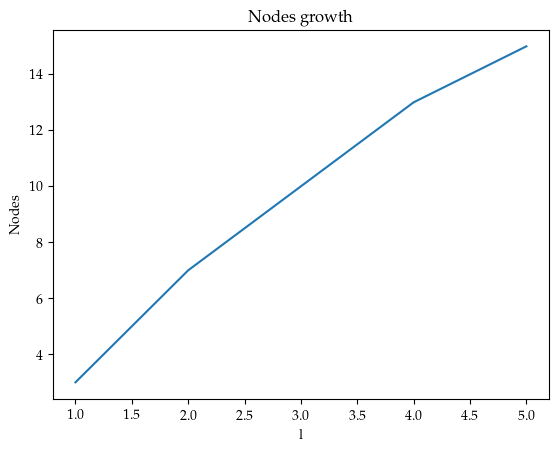

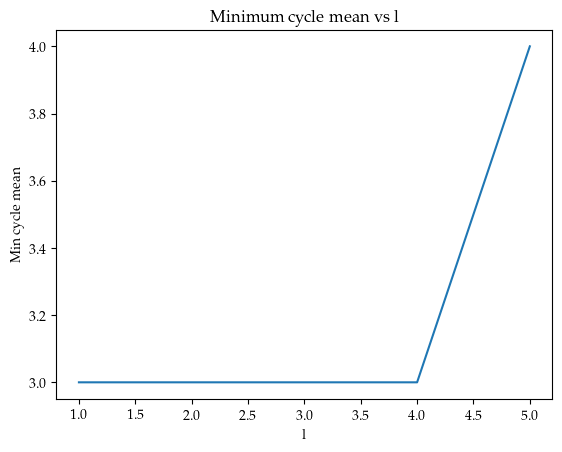

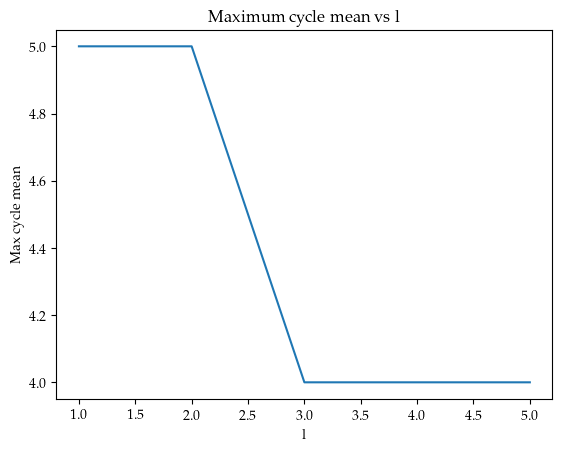

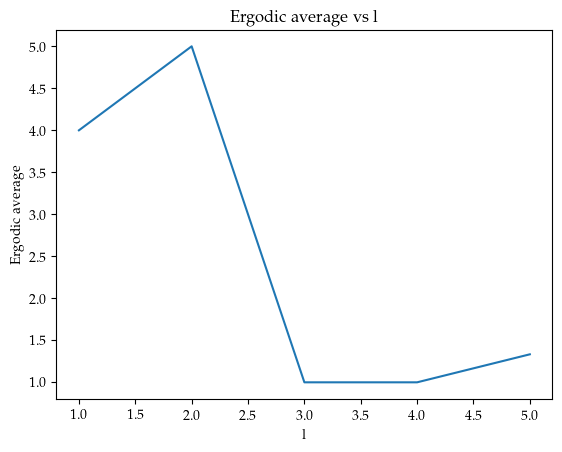

In [20]:
"""
Study structural behavior of the exact symbolic traffic graph
as memory length l increases.

This script assumes that:

    build_complete_symbolic_graph_exact(...)

is already implemented and available.
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Cycle mean (Karp)
# ---------------------------------------------------------------------

def karp_minimum_cycle_mean(G):
  nodes = list(G.nodes())
  n = len(nodes)
  index = {node: i for i, node in enumerate(nodes)}

  dp = np.full((n + 1, n), np.inf)
  dp[0, :] = 0

  for k in range(1, n + 1):
    for v in nodes:
      i = index[v]
      for u in G.predecessors(v):
        j = index[u]
        w = G[u][v]["weight"]
        dp[k, i] = min(dp[k, i], dp[k - 1, j] + w)

  min_mean = np.inf

  for v in range(n):
    max_avg = -np.inf
    for k in range(n):
      if dp[n, v] < np.inf and dp[k, v] < np.inf:
        val = (dp[n, v] - dp[k, v]) / (n - k)
        max_avg = max(max_avg, val)
    min_mean = min(min_mean, max_avg)

  return min_mean


def karp_maximum_cycle_mean(G):
  H = G.copy()
  for u, v in H.edges():
    H[u][v]["weight"] = -H[u][v]["weight"]
  return -karp_minimum_cycle_mean(H)


# ---------------------------------------------------------------------
# Connectivity
# ---------------------------------------------------------------------

def analyze_connectivity(G):
  scc = list(nx.strongly_connected_components(G))
  largest_scc = max(scc, key=len)
  return len(scc), len(largest_scc)


# ---------------------------------------------------------------------
# Ergodic average
# ---------------------------------------------------------------------

def ergodic_average(G):
  nodes = list(G.nodes())
  n = len(nodes)
  index = {node: i for i, node in enumerate(nodes)}

  P = np.zeros((n, n))

  for u in nodes:
    i = index[u]
    succ = list(G.successors(u))
    if succ:
      p = 1.0 / len(succ)
      for v in succ:
        j = index[v]
        P[i, j] = p

  eigvals, eigvecs = np.linalg.eig(P.T)
  idx = np.argmin(np.abs(eigvals - 1))
  pi = np.real(eigvecs[:, idx])
  pi = pi / np.sum(pi)

  avg = 0.0
  for u in nodes:
    i = index[u]
    succ = list(G.successors(u))
    if succ:
      p = pi[i] / len(succ)
      for v in succ:
        avg += p * G[u][v]["weight"]

  return avg


# ---------------------------------------------------------------------
# Wrap your exact generator
# ---------------------------------------------------------------------

def make_builder(K_set, h, A, B, K, Psi, Xi):

  def build_graph(l):
    return build_complete_symbolic_graph_exact(
        l=l,
        K_set=K_set,
        h=h,
        A=A,
        B=B,
        K=K,
        Psi=Psi,
        Xi=Xi
    )

  return build_graph


# ---------------------------------------------------------------------
# Main study
# ---------------------------------------------------------------------

def study_l_growth(build_graph, L_max):

  results = {
      "l": [],
      "nodes": [],
      "edges": [],
      "num_scc": [],
      "largest_scc": [],
      "min_mean": [],
      "max_mean": [],
      "ergodic_avg": [],
  }

  for l in range(1, L_max + 1):

    print(f"\nAnalyzing l = {l}")
    G = build_graph(l)

    num_scc, largest_scc = analyze_connectivity(G)
    min_mean = karp_minimum_cycle_mean(G)
    max_mean = karp_maximum_cycle_mean(G)
    erg_avg = ergodic_average(G)

    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"SCC: {num_scc}")
    print(f"Min mean: {min_mean:.6f}")
    print(f"Max mean: {max_mean:.6f}")
    print(f"Ergodic avg: {erg_avg:.6f}")

    results["l"].append(l)
    results["nodes"].append(G.number_of_nodes())
    results["edges"].append(G.number_of_edges())
    results["num_scc"].append(num_scc)
    results["largest_scc"].append(largest_scc)
    results["min_mean"].append(min_mean)
    results["max_mean"].append(max_mean)
    results["ergodic_avg"].append(erg_avg)

  return results


# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------

def plot_results(results):

  l = results["l"]

  plt.figure()
  plt.plot(l, results["nodes"])
  plt.xlabel("l")
  plt.ylabel("Nodes")
  plt.title("Nodes growth")

  plt.figure()
  plt.plot(l, results["min_mean"])
  plt.xlabel("l")
  plt.ylabel("Min cycle mean")
  plt.title("Minimum cycle mean vs l")

  plt.figure()
  plt.plot(l, results["max_mean"])
  plt.xlabel("l")
  plt.ylabel("Max cycle mean")
  plt.title("Maximum cycle mean vs l")

  plt.figure()
  plt.plot(l, results["ergodic_avg"])
  plt.xlabel("l")
  plt.ylabel("Ergodic average")
  plt.title("Ergodic average vs l")

  plt.show()


builder = make_builder(
    K_set=K_set,
    h=h,
    A=A,
    B=B,
    K=K,
    Psi=Ψ,
    Xi=Ξ
)

results = study_l_growth(builder, L_max=5)
plot_results(results)

In [21]:
"""
Cycle structure analysis of a symbolic graph.

This module:
    - Identifies strongly connected components
    - Detects real cycles (length >= 1)
    - Computes exact mean weight of each cycle
    - Classifies recurrent components
"""

import networkx as nx


def analyze_cycles(G):

  print("\n=== Cycle Structure Analysis ===")

  sccs = list(nx.strongly_connected_components(G))

  print(f"Number of SCC: {len(sccs)}")

  recurrent_components = []

  for i, comp in enumerate(sccs):

    subG = G.subgraph(comp)

    has_cycle = False
    cycles = list(nx.simple_cycles(subG))

    if len(cycles) > 0:
      has_cycle = True
      recurrent_components.append((i, comp, cycles))

    print(f"\nComponent {i}")
    print(f"Size: {len(comp)}")
    print(f"Has cycle: {has_cycle}")

  print("\n=== Detailed Cycle Information ===")

  for idx, comp, cycles in recurrent_components:

    subG = G.subgraph(comp)

    print(f"\nComponent {idx}")
    print(f"Nodes: {comp}")

    for cycle in cycles:

      total_weight = 0
      for j in range(len(cycle)):
        u = cycle[j]
        v = cycle[(j + 1) % len(cycle)]
        total_weight += G[u][v]["weight"]

      mean_weight = total_weight / len(cycle)

      print(f"Cycle: {cycle}")
      print(f"Length: {len(cycle)}")
      print(f"Mean weight: {mean_weight}")

  if len(recurrent_components) == 0:
    print("\nNo recurrent components found.")
  elif len(recurrent_components) == 1 and len(recurrent_components[0][2]) == 1:
    print("\nUnique recurrent cycle detected.")
  else:
    print("\nMultiple recurrent cycles detected.")


if __name__ == "__main__":

  # Use your previously generated G_complete for l = 5
  analyze_cycles(G_complete)


=== Cycle Structure Analysis ===
Number of SCC: 4

Component 0
Size: 1
Has cycle: True

Component 1
Size: 1
Has cycle: False

Component 2
Size: 1
Has cycle: False

Component 3
Size: 4
Has cycle: True

=== Detailed Cycle Information ===

Component 0
Nodes: {(5, 5)}
Cycle: [(5, 5)]
Length: 1
Mean weight: 5.0

Component 3
Nodes: {(4, 4), (3, 3), (3, 4), (4, 3)}
Cycle: [(3, 3)]
Length: 1
Mean weight: 3.0
Cycle: [(4, 4)]
Length: 1
Mean weight: 4.0
Cycle: [(4, 4), (4, 3), (3, 3), (3, 4)]
Length: 4
Mean weight: 3.5
Cycle: [(4, 4), (4, 3), (3, 4)]
Length: 3
Mean weight: 3.6666666666666665
Cycle: [(3, 3), (3, 4), (4, 3)]
Length: 3
Mean weight: 3.3333333333333335
Cycle: [(3, 4), (4, 3)]
Length: 2
Mean weight: 3.5

Multiple recurrent cycles detected.


In [22]:
"""
Symbolic Order vs Disorder Analysis

Measures:
    - Spectral radius
    - Topological entropy
    - Exponential growth of admissible paths
    - Largest strongly connected component
    - Structural sensitivity to symbolic perturbation
"""

import numpy as np
import networkx as nx
import random


# ---------------------------------------------------------------------
# Spectral radius and entropy
# ---------------------------------------------------------------------

def spectral_entropy(G):

  A = nx.to_numpy_array(G, weight=None)
  eigvals = np.linalg.eigvals(A)
  rho = max(abs(eigvals))

  if rho > 0:
    entropy = np.log(rho)
  else:
    entropy = 0.0

  return rho, entropy


# ---------------------------------------------------------------------
# Growth of admissible paths
# ---------------------------------------------------------------------

def path_growth_rate(G, n_max=8):

  A = nx.to_numpy_array(G, weight=None)
  growth = []

  A_power = np.identity(A.shape[0])

  for n in range(1, n_max + 1):
    A_power = A_power @ A
    total_paths = np.sum(A_power)
    growth.append(total_paths)

  return growth


# ---------------------------------------------------------------------
# Largest SCC ratio
# ---------------------------------------------------------------------

def largest_scc_ratio(G):

  scc = list(nx.strongly_connected_components(G))
  largest = max(scc, key=len)

  return len(largest) / G.number_of_nodes()


# ---------------------------------------------------------------------
# Sensitivity to edge removal
# ---------------------------------------------------------------------

def symbolic_sensitivity(G, trials=20):

  original_scc = len(list(nx.strongly_connected_components(G)))
  original_rho, _ = spectral_entropy(G)

  impacts = []

  edges = list(G.edges())

  if len(edges) == 0:
    return 0

  for _ in range(min(trials, len(edges))):

    G_copy = G.copy()
    e = random.choice(edges)
    G_copy.remove_edge(*e)

    new_scc = len(list(nx.strongly_connected_components(G_copy)))
    new_rho, _ = spectral_entropy(G_copy)

    delta_scc = new_scc - original_scc
    delta_rho = abs(new_rho - original_rho)

    impacts.append((delta_scc, delta_rho))

  return impacts


# ---------------------------------------------------------------------
# Main analysis
# ---------------------------------------------------------------------

def order_disorder_report(G):

  print("\n==============================")
  print("Order vs Disorder Report")
  print("==============================")

  rho, entropy = spectral_entropy(G)

  print(f"Spectral radius: {rho:.6f}")
  print(f"Topological entropy: {entropy:.6f}")

  growth = path_growth_rate(G)
  print("\nPath growth (total admissible paths length n):")
  for i, val in enumerate(growth):
    print(f"n={i+1}: {val}")

  scc_ratio = largest_scc_ratio(G)
  print(f"\nLargest SCC ratio: {scc_ratio:.4f}")

  impacts = symbolic_sensitivity(G)

  print("\nSensitivity to symbolic perturbation:")
  for i, (dscc, drho) in enumerate(impacts):
    print(f"Trial {i+1}: ΔSCC={dscc}, Δrho={drho:.6f}")

  print("\nInterpretation guidelines:")
  print("Entropy near zero -> ordered regime.")
  print("Large spectral radius -> high combinatorial growth.")
  print("Large SCC ratio -> strong mixing.")
  print("High sensitivity -> structural fragility.")
  print("==============================")

In [23]:
order_disorder_report(G_complete)


Order vs Disorder Report
Spectral radius: 2.000000
Topological entropy: 0.693147

Path growth (total admissible paths length n):
n=1: 15.0
n=2: 31.0
n=3: 63.0
n=4: 127.0
n=5: 255.0
n=6: 511.0
n=7: 1023.0
n=8: 2047.0

Largest SCC ratio: 0.5714

Sensitivity to symbolic perturbation:
Trial 1: ΔSCC=1, Δrho=0.381966
Trial 2: ΔSCC=0, Δrho=0.000000
Trial 3: ΔSCC=1, Δrho=0.381966
Trial 4: ΔSCC=0, Δrho=0.000000
Trial 5: ΔSCC=0, Δrho=0.000000
Trial 6: ΔSCC=0, Δrho=0.160713
Trial 7: ΔSCC=0, Δrho=0.245122
Trial 8: ΔSCC=0, Δrho=0.160713
Trial 9: ΔSCC=0, Δrho=0.245122
Trial 10: ΔSCC=0, Δrho=0.000000
Trial 11: ΔSCC=0, Δrho=0.000000
Trial 12: ΔSCC=1, Δrho=0.381966
Trial 13: ΔSCC=0, Δrho=0.000000
Trial 14: ΔSCC=1, Δrho=0.381966
Trial 15: ΔSCC=0, Δrho=0.160713

Interpretation guidelines:
Entropy near zero -> ordered regime.
Large spectral radius -> high combinatorial growth.
Large SCC ratio -> strong mixing.
High sensitivity -> structural fragility.


In [219]:
import random


def generate_sequence_from_graph(G, length, seed=None):
  """
  Gera uma sequência de símbolos k baseada em um passeio aleatório no grafo.

  Args:
      G (nx.DiGraph): Grafo simbólico onde os nós são tuplas de comprimento l.
      length (int): Comprimento total da sequência de símbolos desejada.
      seed (int, optional): Semente para reprodutibilidade.

  Returns:
      list: Sequência de inteiros k_i pertencente à linguagem do grafo.
  """
  if not G.nodes:
    raise ValueError(
        "O grafo está vazio. Não é possível gerar sequências.")

  if seed is not None:
    random.seed(seed)

  nodes = list(G.nodes)
  l_window = len(nodes[0])

  if length < l_window:
    # Retorna apenas o prefixo de um nó aleatório
    return list(random.choice(nodes)[:length])

  # Tentativa de gerar a sequência completa
  max_retries = 100
  for _ in range(max_retries):
    current_node = random.choice(nodes)
    sequence = list(current_node)

    while len(sequence) < length:
      successors = list(G.successors(current_node))

      if not successors:
        # Dead-end atingido: o grafo não é fortemente conexo neste ramo
        break

      # Seleciona o próximo nó e extrai o novo símbolo (último da tupla)
      current_node = random.choice(successors)
      sequence.append(current_node[-1])

    if len(sequence) == length:
      return sequence

  raise RuntimeError(
      "Não foi possível gerar uma sequência do comprimento desejado devido a dead-ends no grafo.")


# ============================================================
# Exemplo de uso
# ============================================================
seq_length = 20
my_seed = 20
sequence = generate_sequence_from_graph(G_sampled, seq_length, seed=my_seed)
print(f"Sequência gerada: {sequence}")

Sequência gerada: [4, 3, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


In [287]:
import numpy as np
from scipy.signal import cont2discrete
from z3 import Solver, Real, sat, Q, Or, And
from fractions import Fraction as PyFraction


def to_z3_rational(matrix):
  """
  Converte matrizes para o formato racional do Z3 para evitar erros de 
  arredondamento e garantir precisão analítica.
  """
  res = []
  for row in matrix:
    res_row = []
    for val in row:
      f = PyFraction(float(val)).limit_denominator(10**12)
      res_row.append(Q(f.numerator, f.denominator))
    res.append(res_row)
  return res


def solve_x0_absolute_certainty_v2(sequence, A_c, B_c, K, Xi, Psi, h, iet_max):
  """
  Inversor exato incorporando a condição de timeout (iet_max).
  Garante satisfatibilidade lógica para o modelo SETM com limite temporal.
  """
  nx = A_c.shape[0]
  m_max_steps = int(round(iet_max / h))

  # 1. Discretização ZOH
  sys_d = cont2discrete((A_c, B_c, np.zeros((1, nx)),
                        np.zeros((1, B_c.shape[1]))), h, method='zoh')
  Ad, Bd = sys_d[0], sys_d[1]

  def get_phi_m_np(m):
    """Calcula o operador de transição Phi(m)."""
    sum_ad = np.zeros_like(Ad)
    for p in range(m):
      sum_ad += np.linalg.matrix_power(Ad, p)
    return np.linalg.matrix_power(Ad, m) + sum_ad @ Bd @ K

  # 2. Setup do Solver
  solver = Solver()
  x0 = [Real(f'x0_{i}') for i in range(nx)]

  # Restrição de exclusão da solução nula
  solver.add(sum([v**2 for v in x0]) >= Q(1, 100))

  g_acc_np = np.eye(nx)

  for m_i in sequence:
    if m_i > m_max_steps:
      raise ArithmeticError(
          f"Sequência impossível: m_i ({m_i}) excede iet_max_steps ({m_max_steps})")

    for j in range(1, m_i + 1):
      # Cálculo da matriz de gatilho M_j
      phi_j = get_phi_m_np(j)
      I = np.eye(nx)
      M_j = phi_j.T @ Psi @ phi_j - (I - phi_j).T @ Xi @ (I - phi_j)

      # Projeção retroativa e simetrização
      M_p_np = 0.5 * (g_acc_np.T @ M_j @ g_acc_np +
                      (g_acc_np.T @ M_j @ g_acc_np).T)
      M_p_z3 = to_z3_rational(M_p_np)

      # Expressão simbólica da forma quadrática
      quad_form = sum(x0[r] * M_p_z3[r][c] * x0[c]
                      for r in range(nx) for c in range(nx))

      if j < m_i:
        # Condição obrigatória: Não pode ter disparado antes de m_i
        # Isso implica que a condição quadrática era >= 0
        solver.add(quad_form >= 0)
      else:
        # Instante j = m_i
        if m_i < m_max_steps:
          # O disparo ocorreu OBRIGATORIAMENTE pela condição quadrática
          solver.add(quad_form < 0)
        else:
          # m_i == m_max_steps: O disparo ocorreu por timeout.
          # A condição quadrática é irrelevante aqui (pode ser >= 0 ou < 0).
          # Não adicionamos restrição para permitir qualquer estado que não tenha disparado antes.
          pass

    # Evolução do estado acumulado para o próximo evento
    g_acc_np = get_phi_m_np(m_i) @ g_acc_np

  # 3. Verificação de Satisfatibilidade
  if solver.check() == sat:
    model = solver.model()
    return np.array([float(model[v].as_fraction()) for v in x0])
  else:
    raise ArithmeticError(
        "Inviabilidade Lógica: A sequência é matematicamente impossível para este sistema.")


# --- Exemplo de Uso ---
iet_max = config["design_params"]['iet_max']
n = 2
A, B, _, _ = plant.export_matrices_jit()
K = prob_results['controller']['K']
Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
h = sampling_period
sequence = (5, 4)
try:
  x0_exact = solve_x0_absolute_certainty_v2(
      sequence, A, B, K, Ξ, Ψ, h, iet_max)
  print(f"Estado inicial exato: {x0_exact}")
  # x0 = np.array([[1.0], [0.1]], dtype=np.float32)
  x0 = np.array([[x0_exact[0]], [x0_exact[1]]], dtype=np.float32)
  _, _, _, event_times = closed_loop_setm(
      x0, config, prob_results)
  inter_event_times = nm.compute_deltas(event_times)

  print((inter_event_times / sampling_period)[1:len(sequence)+1])
except Exception as e:
  print(e)

Inviabilidade Lógica: A sequência é matematicamente impossível para este sistema.


In [221]:
n = 2
A, B, _, _ = plant.export_matrices_jit()
K = prob_results['controller']['K']
Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
h = sampling_period
sequence = (3, 4, 5, 5, 5, 5, 5, 5)